In [1]:
# ============================================================
#  NOTEBOOK 05: FORECASTING DE DEMANDA CON PROPHET (Grupo 3)
#  Proyeccion preliminar de atenciones para el EP
# ============================================================
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. Cargar el dataset de atenciones
df = pd.read_csv('../data/raw/atenciones_essalud.csv')
df['fecha_atencion'] = pd.to_datetime(df['fecha_atencion'])

# 2. Elegir UNA especialidad para la proyeccion (Emergencia, la mas critica)
especialidad_objetivo = 'Emergencia'
df_esp = df[df['especialidad'] == especialidad_objetivo]

# 3. Contar atenciones por dia (serie temporal)
serie = df_esp.groupby('fecha_atencion').size().reset_index()
serie.columns = ['ds', 'y']   # Prophet exige estos nombres: ds=fecha, y=valor

print(f"Serie temporal de '{especialidad_objetivo}' preparada:")
print(f"  Dias con datos: {len(serie)}")
print(f"  Rango: {serie['ds'].min().date()} a {serie['ds'].max().date()}")
print(serie.head())

Serie temporal de 'Emergencia' preparada:
  Dias con datos: 1096
  Rango: 2022-01-01 a 2024-12-31
          ds    y
0 2022-01-01  160
1 2022-01-02  113
2 2022-01-03  142
3 2022-01-04  178
4 2022-01-05  143


In [2]:
# ============================================================
#  ENTRENAR PROPHET Y PROYECTAR LAS PROXIMAS 12 SEMANAS
# ============================================================

# 1. Crear y entrenar el modelo Prophet
#    yearly_seasonality=True -> que capture el patron anual (estacionalidad)
modelo = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
modelo.fit(serie)

# 2. Crear fechas futuras: 84 dias = 12 semanas hacia adelante
futuro = modelo.make_future_dataframe(periods=84)

# 3. Generar la prediccion
prediccion = modelo.predict(futuro)

# 4. Mostrar las ultimas predicciones (el futuro proyectado)
print("Proyeccion de demanda para las proximas semanas:")
cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
print(prediccion[cols].tail(10).to_string(index=False))

print("\n  yhat       = demanda proyectada (estimacion central)")
print("  yhat_lower = escenario optimista (menos demanda)")
print("  yhat_upper = escenario pesimista (mas demanda)")

23:42:00 - cmdstanpy - INFO - Chain [1] start processing
23:42:00 - cmdstanpy - INFO - Chain [1] done processing


Proyeccion de demanda para las proximas semanas:
        ds       yhat  yhat_lower  yhat_upper
2025-03-16 148.251650  133.737598  163.232651
2025-03-17 147.648860  132.262402  162.258798
2025-03-18 145.628425  130.786392  159.371129
2025-03-19 145.285331  129.698547  159.954925
2025-03-20 141.613494  127.288183  156.034800
2025-03-21 143.877107  128.596579  158.683073
2025-03-22 140.379751  126.839862  155.290429
2025-03-23 138.367765  122.245435  153.684011
2025-03-24 136.417961  121.053114  151.952993
2025-03-25 133.101093  118.109082  148.472121

  yhat       = demanda proyectada (estimacion central)
  yhat_lower = escenario optimista (menos demanda)
  yhat_upper = escenario pesimista (mas demanda)


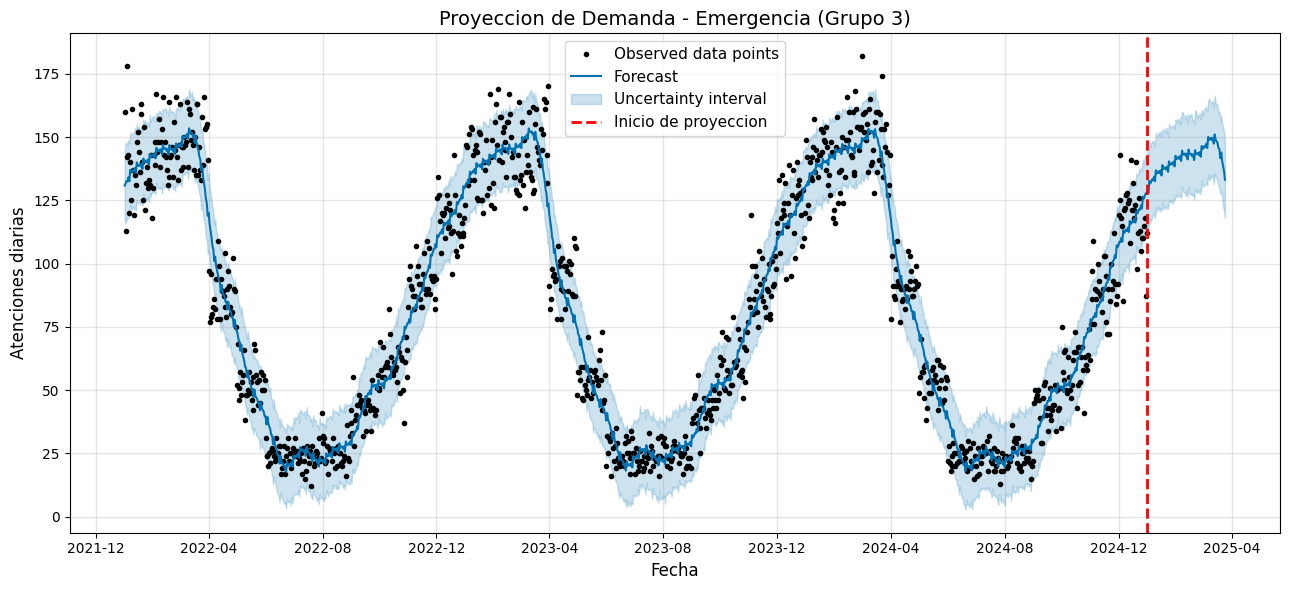

INTERPRETACION para la sustentacion:
- Los puntos negros son la demanda historica real (2022-2024).
- La linea azul es la tendencia que Prophet aprendio.
- A la derecha de la linea roja esta la PROYECCION futura.
- La banda celeste es el intervalo de confianza (escenarios).
- Prophet capta la estacionalidad: la demanda sube y baja segun la epoca.


In [3]:
# ============================================================
#  GRAFICO DE LA PROYECCION (lo que se muestra en el EP)
# ============================================================

fig = modelo.plot(prediccion, figsize=(13, 6))
plt.title(f'Proyeccion de Demanda - {especialidad_objetivo} (Grupo 3)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Atenciones diarias', fontsize=12)

# Linea vertical que marca donde termina lo real y empieza la proyeccion
import pandas as pd
fecha_corte = serie['ds'].max()
plt.axvline(x=fecha_corte, color='red', linestyle='--', linewidth=2, label='Inicio de proyeccion')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("INTERPRETACION para la sustentacion:")
print("- Los puntos negros son la demanda historica real (2022-2024).")
print("- La linea azul es la tendencia que Prophet aprendio.")
print("- A la derecha de la linea roja esta la PROYECCION futura.")
print("- La banda celeste es el intervalo de confianza (escenarios).")
print("- Prophet capta la estacionalidad: la demanda sube y baja segun la epoca.")